# Regressione con Grid Search


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.svm import SVR
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error

In [2]:
data = fetch_california_housing()

X, y = data.data, data.target

In [3]:
# data splitting

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    shuffle=True,
    test_size=0.2,
    random_state=42
)

In [4]:
# scaling dei dati

scaler = StandardScaler()
X_train_scaled = X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# modello base

svr_base = SVR(kernel="linear", C=1.0, epsilon=0.1)
svr_base.fit(X_train_scaled, y_train)
y_pred_base = svr_base.predict(X_test_scaled)
mse_base = mean_squared_error(y_test, y_pred_base)

In [ ]:
# impostazione del dizionario per la search grid

param_grid = {
    "kernel": ["linear"],
    "C": [0.1, 1.0, 10.0],
    "epsilon": [0.05, 0.1, 0.2]
}

In [8]:
# ricerca di dearch grid ottimale girando il dizionario che gli abbiamo dato (MOLTO LENTO!!)

grid = GridSearchCV(SVR(), param_grid=param_grid, cv=5, scoring="neg_mean_squared_error")
grid.fit(X_train_scaled, y_train)

best_svr = grid.best_estimator_
y_pred_best = best_svr.predict(X_test_scaled)
mse_best = mean_squared_error(y_test, y_pred_best)

In [9]:
print(f"Migliori parametri:\n{grid.best_params_}")
print(f"MSE_base:\t{mse_base:.4f}")
print(f"MSE_best:\t{mse_best:.4f}")

Migliori parametri:
{'C': 0.1, 'epsilon': 0.2, 'kernel': 'linear'}
MSE_base:	0.5792
MSE_best:	0.5781


In [13]:
# modello 2d

X_scaled_all = np.vstack([X_train_scaled, X_test_scaled])
y_all = np.hstack([y_train, y_test])

pca = PCA(n_components= 2)
X_pca = pca.fit_transform(X_scaled_all)

In [15]:
X_pca_1 = X_pca[:,0].reshape(-1, 1)

svr_base_1d = SVR(kernel="linear", C=1.0, epsilon=0.1)
svr_base_1d.fit(X_pca_1, y_all)
y_pred_base_1d = svr_base_1d.predict(X_pca_1)

best_svr_1d = SVR(**grid.best_params_)
best_svr_1d.fit(X_pca_1, y_all)
y_pred_best_1d = best_svr_1d.predict(X_pca_1)

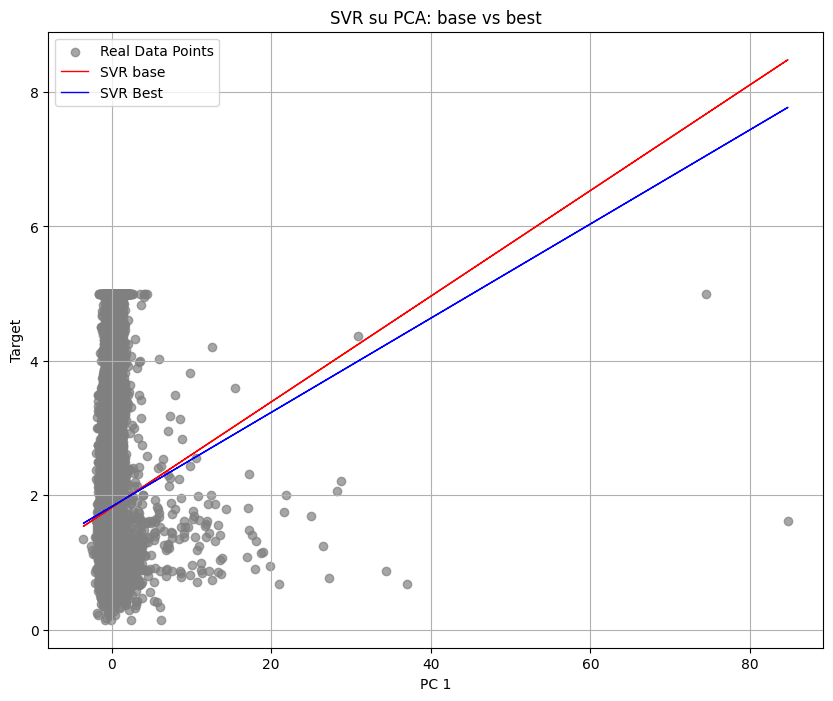

In [16]:
# plot di entrambi i mdetodi

plt.figure(figsize=(10, 8))
plt.scatter(X_pca_1, y_all, color="gray", alpha=0.7, label="Real Data Points")
plt.plot(X_pca_1, y_pred_base_1d, color="red", label="SVR base", linewidth=1)
plt.plot(X_pca_1, y_pred_best_1d, color="blue", label="SVR Best", linewidth=1)
plt.xlabel("PC 1")
plt.ylabel("Target")
plt.title("SVR su PCA: base vs best")
plt.legend()
plt.grid(True)
plt.show()